In [20]:
import pandas as pd
from pathlib import Path
import re
import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

In [2]:
path = Path(__name__).parent

In [3]:
rtrs_brazil = pd.read_csv( path / "../2_DataProcessing/csv_result/amazonia_rtrs.csv")

In [4]:
def clean_string(input_string):
    cleaned_string = unidecode.unidecode(input_string.lower())
    return re.sub(r'[^a-z0-9\s]', ' ', re.sub(r'\s+', ' ', cleaned_string))

In [5]:
for i in rtrs_brazil.iloc[:, 13:]:
    rtrs_brazil[i] = rtrs_brazil[i].map(lambda x: clean_string(x))

In [6]:
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

def avaliar_sentimento(frase):
    inputs = tokenizer(frase, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)

    sentiment_class = outputs.logits.argmax().item()

    sentiment_labels = ["Muito Negativo", "Negativo", "Neutro", "Positivo", "Muito Positivo"]
    sentiment = sentiment_labels[sentiment_class]
    return sentiment

In [8]:
#Testando a função

frases = ["Eu amo esse filme, é incrível!", "Este produto é terrível e não funciona."]

for frase in frases:
    sentimento = avaliar_sentimento(frase)
    print(sentimento)

Muito Positivo
Muito Negativo


In [9]:
rtrs_sentiment_analysis = rtrs_brazil.copy(deep=True)

for i in rtrs_brazil.iloc[:, 13:]:
    rtrs_sentiment_analysis[i] = rtrs_brazil[i].map(lambda x: avaliar_sentimento(x))

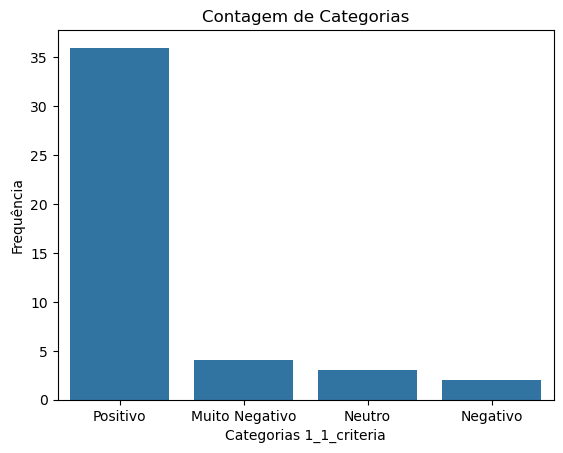

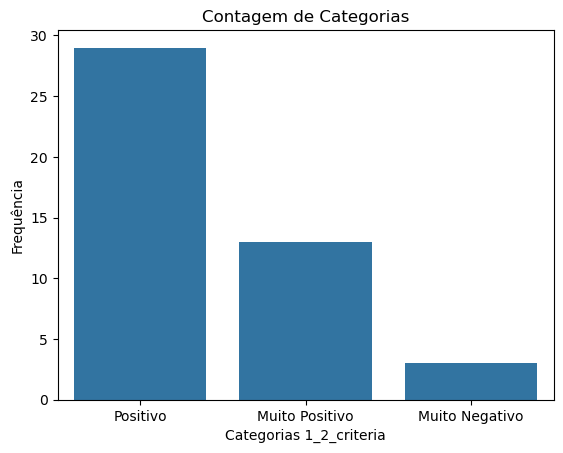

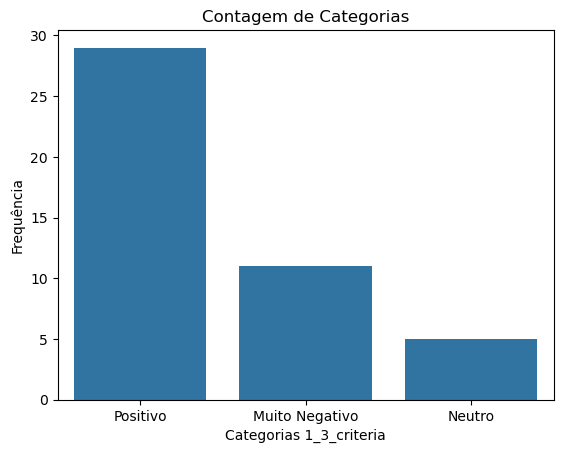

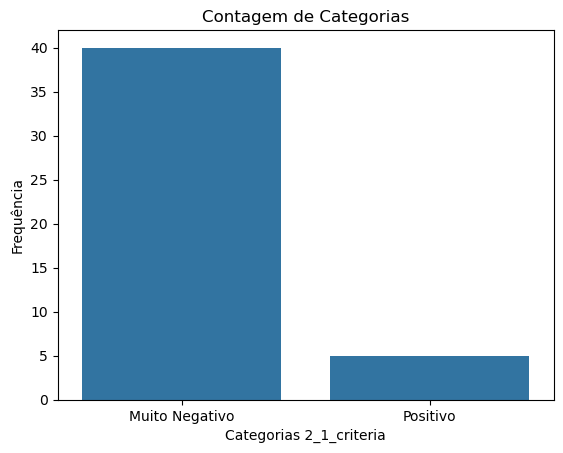

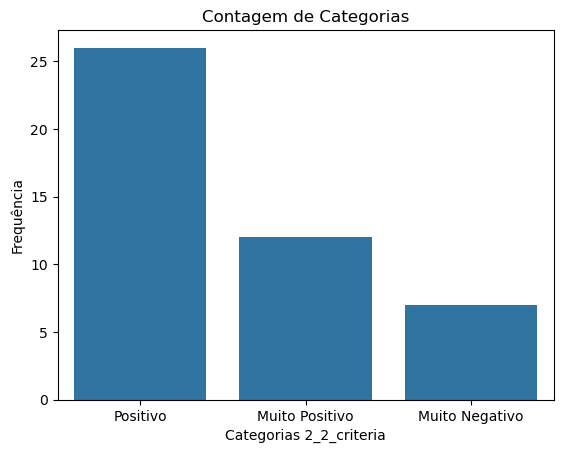

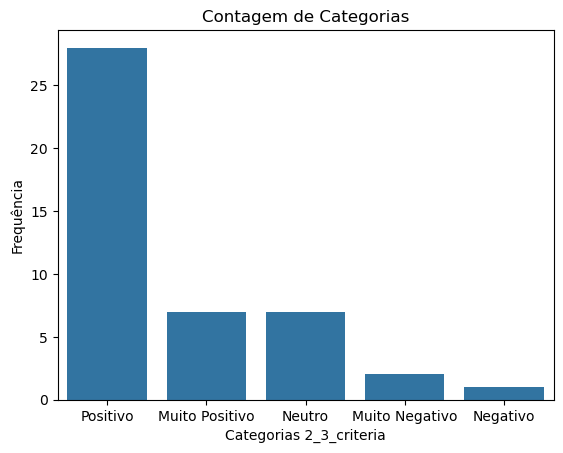

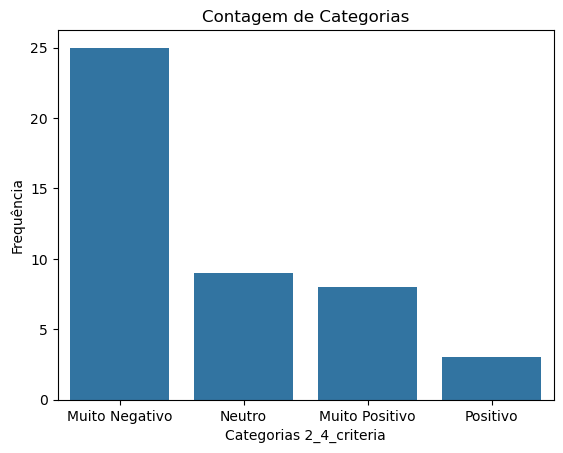

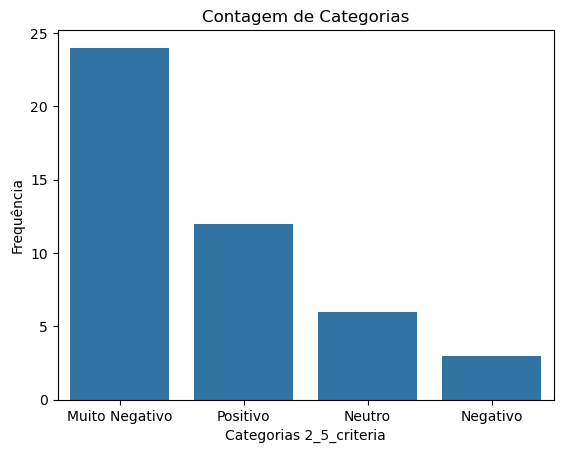

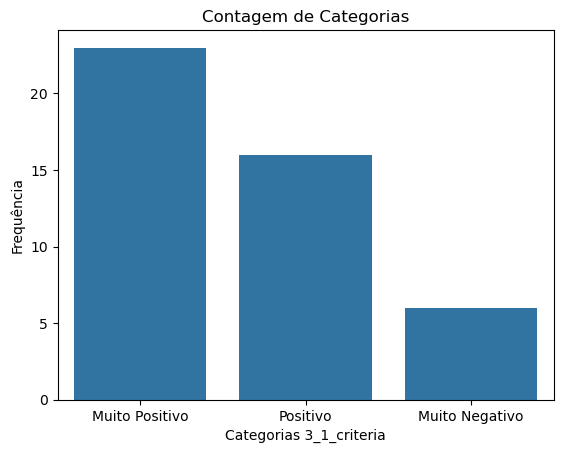

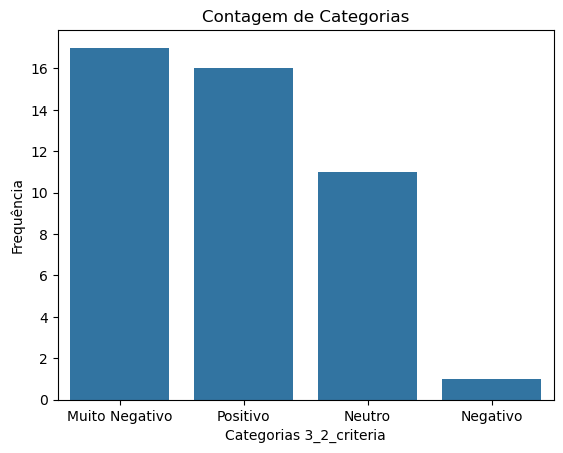

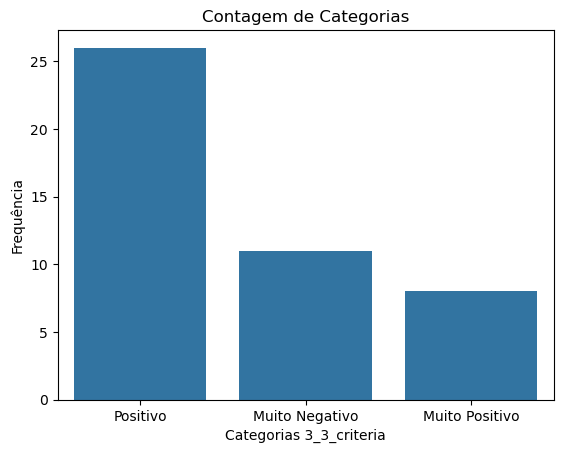

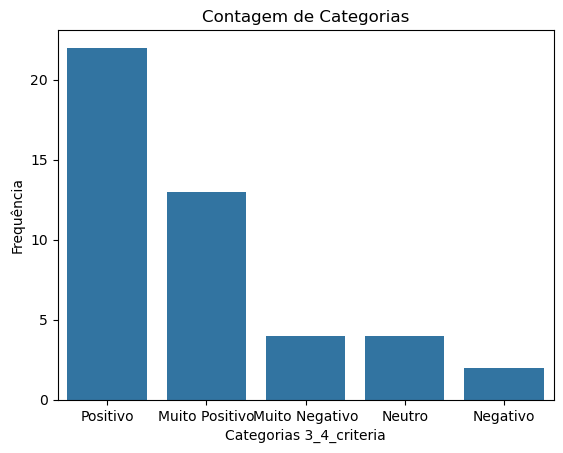

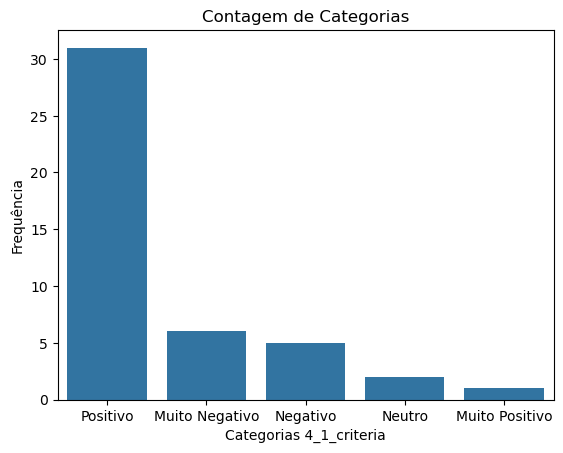

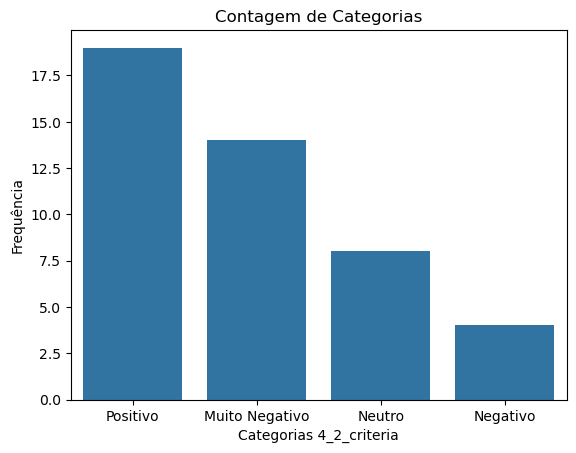

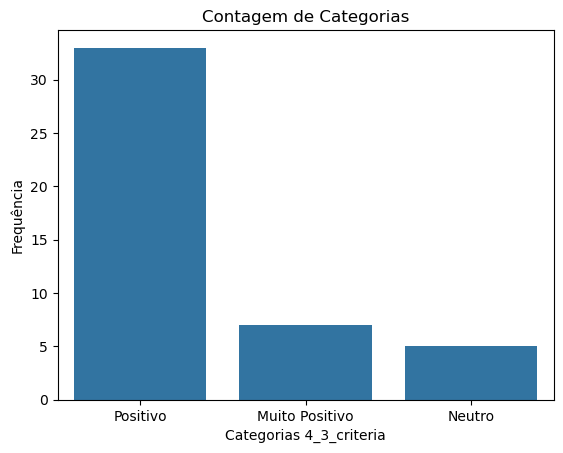

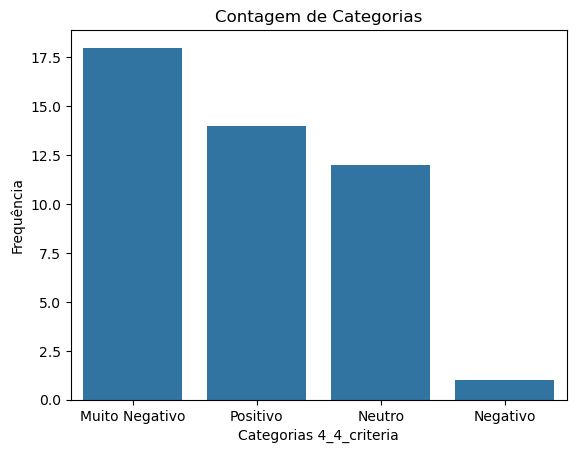

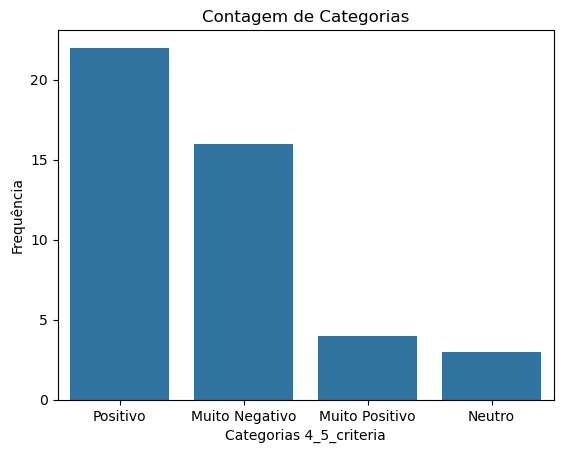

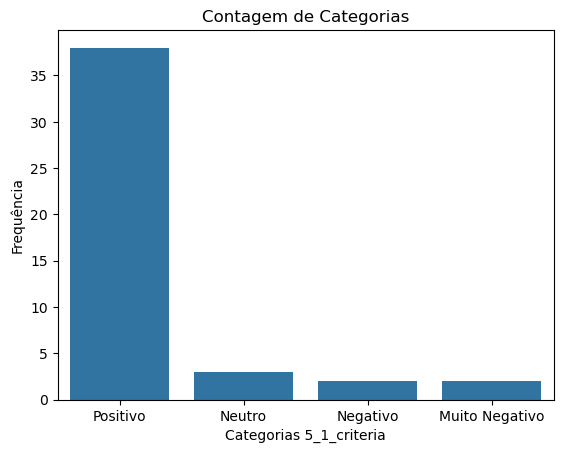

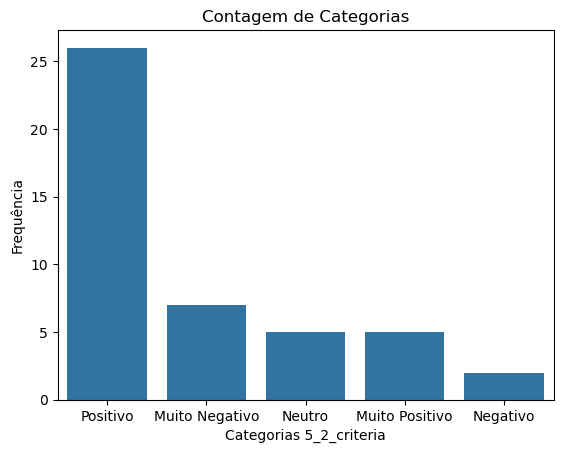

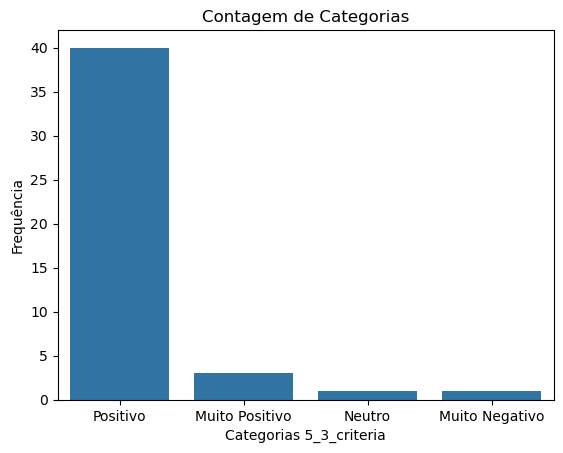

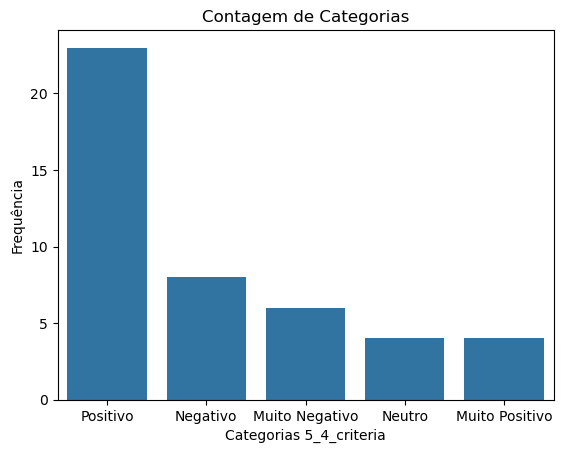

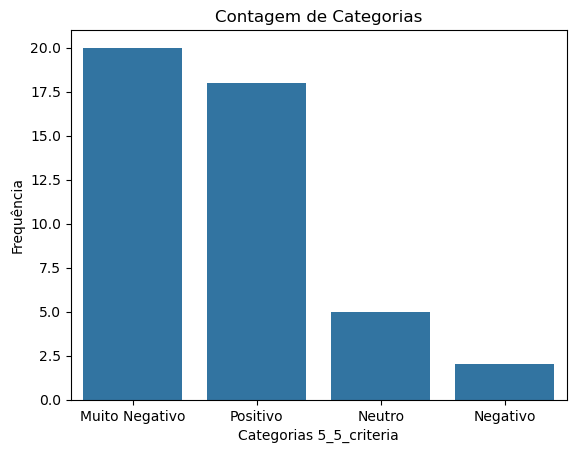

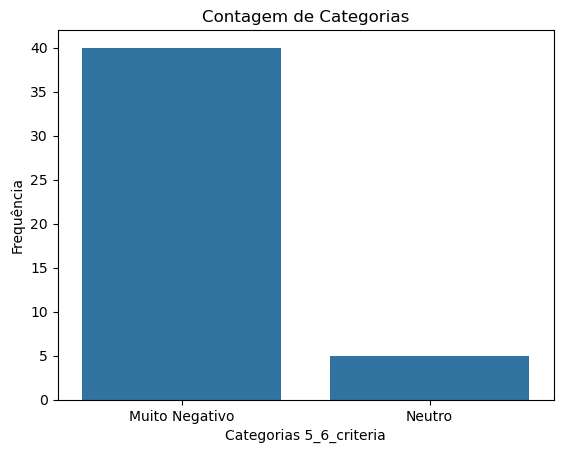

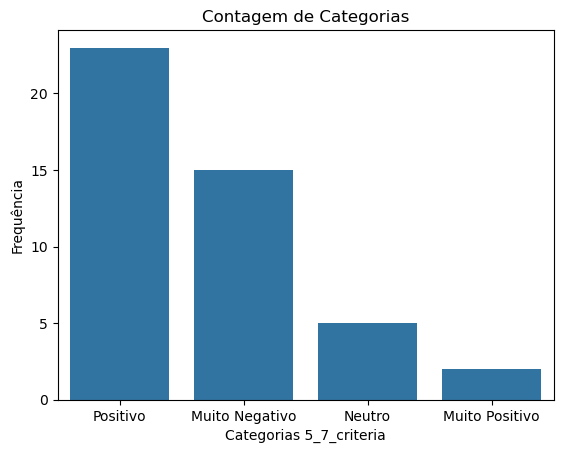

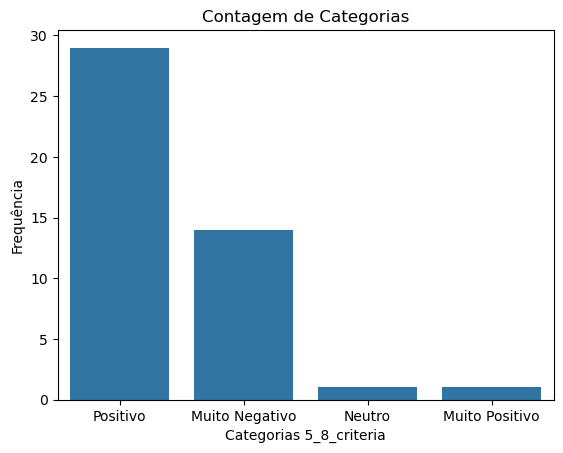

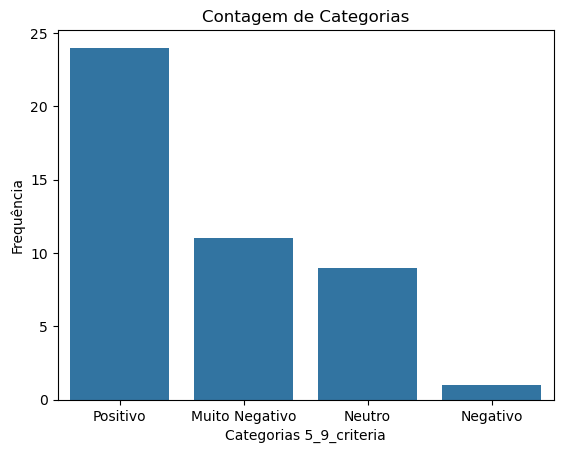

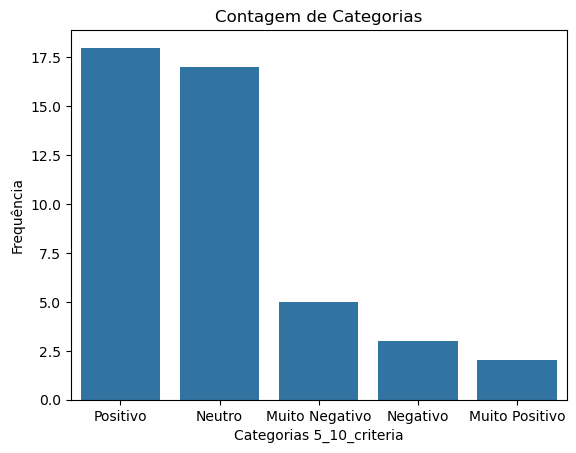

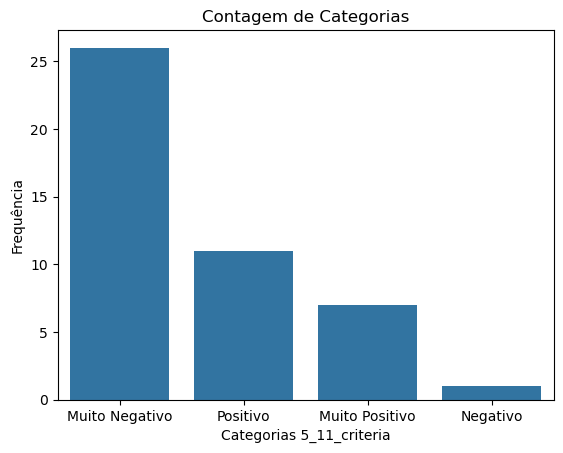

In [22]:
for col in rtrs_sentiment_analysis.iloc[:, 13:]:
    frequencia = rtrs_sentiment_analysis[col].value_counts()
    sns.barplot(x=frequencia.index, y=frequencia.values)
    plt.xlabel(f'Categorias {col}')
    plt.ylabel('Frequência')
    plt.title('Contagem de Categorias')
    plt.show()